In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def my_dot(a, b):
    result = 0

    for i in range(len(a)):
        result += a[i] * b[i]

        return result
    


a = np.array([3, 0])
b = np.array([2, 2])

print("My dot:", my_dot(a, b))
print("NumPy:", np.dot(a, b))

My dot: 6
NumPy: 6


In [3]:
def my_bucaq(a, b):

    dot = np.dot(a, b)

    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    cos_theta = dot / (norm_a * norm_b)
    angle_rad = np.arccos(cos_theta)
    angle_deg = np.degrees(angle_rad)

    return angle_deg

a = np.array([3, 0])
b = np.array([2, 2])

print(my_bucaq(a, b))


45.00000000000001


In [5]:
def my_projection (a, b):

    dot = np.dot(a, b)
    norm_squared = np.dot(a, a)
    proj = (dot / norm_squared) * a

    return proj

a = np.array([3, 0])
b = np.array([2, 2])

proj = my_projection(a, b)

print(proj)

[2. 0.]


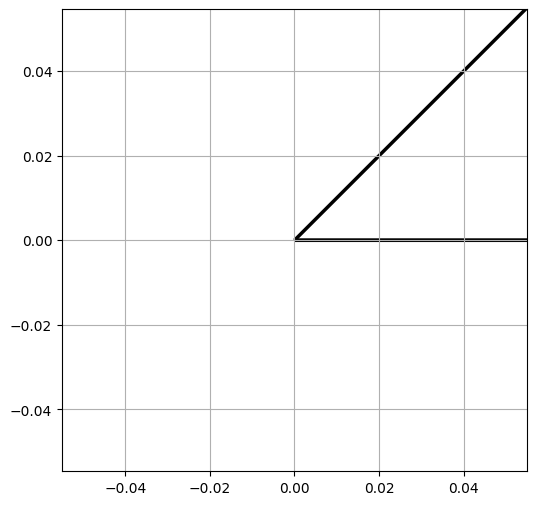

In [7]:
a = np.array([3, 0])
b = np.array([2, 2])

proj = my_projection(a, b)

plt.figure(figsize=(6,6))

plt.quiver(0, 0, a[0], a[1],
           angles='xy', scale_units='xy', scale=1)

plt.quiver(0, 0, b[0], b[1],
           angles='xy', scale_units='xy', scale=1)

plt.quiver(0, 0, proj[0], proj[1],
           angles='xy', scale_units='xy', scale=1)

plt.xlim(-1, 5)
plt.ylim(-1, 5)

plt.grid(True)
plt.axis('equal')

plt.show()

In [8]:
A = np.array([
    [2, 1],
    [1, 2]
])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[3. 1.]

Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


In [9]:
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]

    sol = A @ v
    sag = lam * v

    print(f"Eigenvalue{i}: λ{lam}")
    print(f"   A·v   = {sol}")
    print(f"   λ·v   = {sag}")
    print(f"Equal? {np.allclose(sol, sag)}")

Eigenvalue0: λ3.0
   A·v   = [2.12132034 2.12132034]
   λ·v   = [2.12132034 2.12132034]
Equal? True
Eigenvalue1: λ1.0
   A·v   = [-0.70710678  0.70710678]
   λ·v   = [-0.70710678  0.70710678]
Equal? True


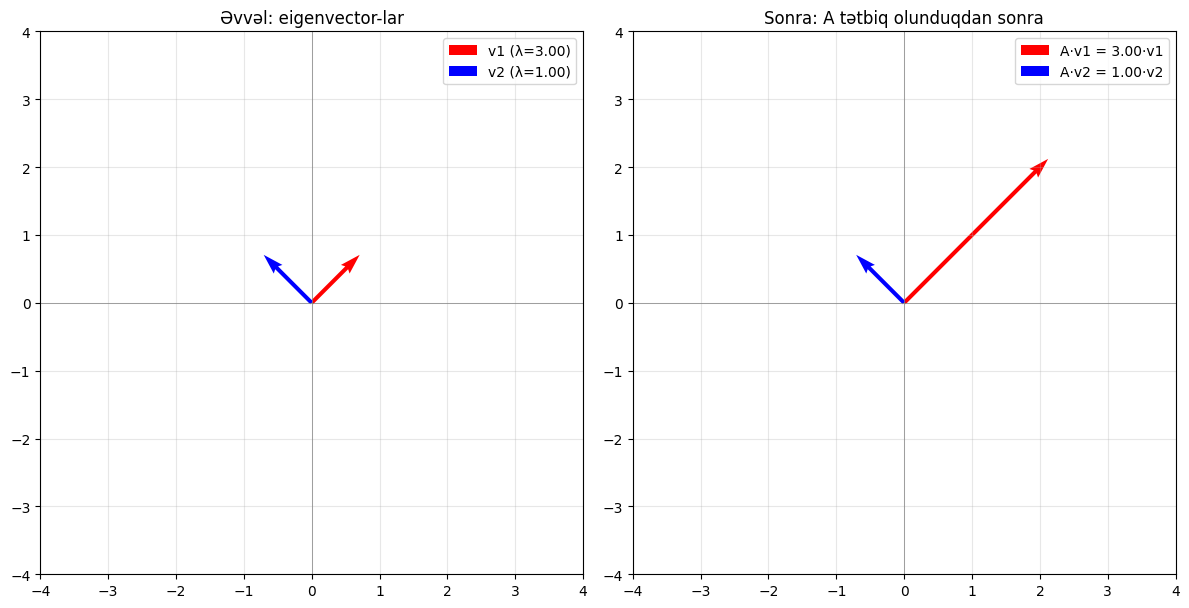

In [10]:
A = np.array([[2, 1], [1, 2]])
eigenvalues, eigenvectors = np.linalg.eig(A)

v1 = eigenvectors[:, 0]
v2 = eigenvectors[:, 1]
lam1 = eigenvalues[0]
lam2 = eigenvalues[1]

# Transformasiyadan sonra
Av1 = A @ v1
Av2 = A @ v2

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# SOL ŞƏKİL: əvvəl
ax = axes[0]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, 
          color='red', label=f'v1 (λ={lam1:.2f})')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', label=f'v2 (λ={lam2:.2f})')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Əvvəl: eigenvector-lar')
ax.legend()

# SAĞ ŞƏKİL: sonra
ax = axes[1]
ax.quiver(0, 0, Av1[0], Av1[1], angles='xy', scale_units='xy', scale=1, 
          color='red', label=f'A·v1 = {lam1:.2f}·v1')
ax.quiver(0, 0, Av2[0], Av2[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', label=f'A·v2 = {lam2:.2f}·v2')
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Sonra: A tətbiq olunduqdan sonra')
ax.legend()

plt.tight_layout()
plt.show()

ADİ VEKTOR (u = [1, 0]):
  u  = [1 0], uzunluq = 1.000
  Au = [2 1], uzunluq = 2.236
  İstiqamət dəyişikliyi: 26.57°

EIGENVECTOR (v = v1):
  v  = [0.70710678 0.70710678], uzunluq = 1.000
  Av = [2.12132034 2.12132034], uzunluq = 3.000
  İstiqamət dəyişikliyi: 0.00°


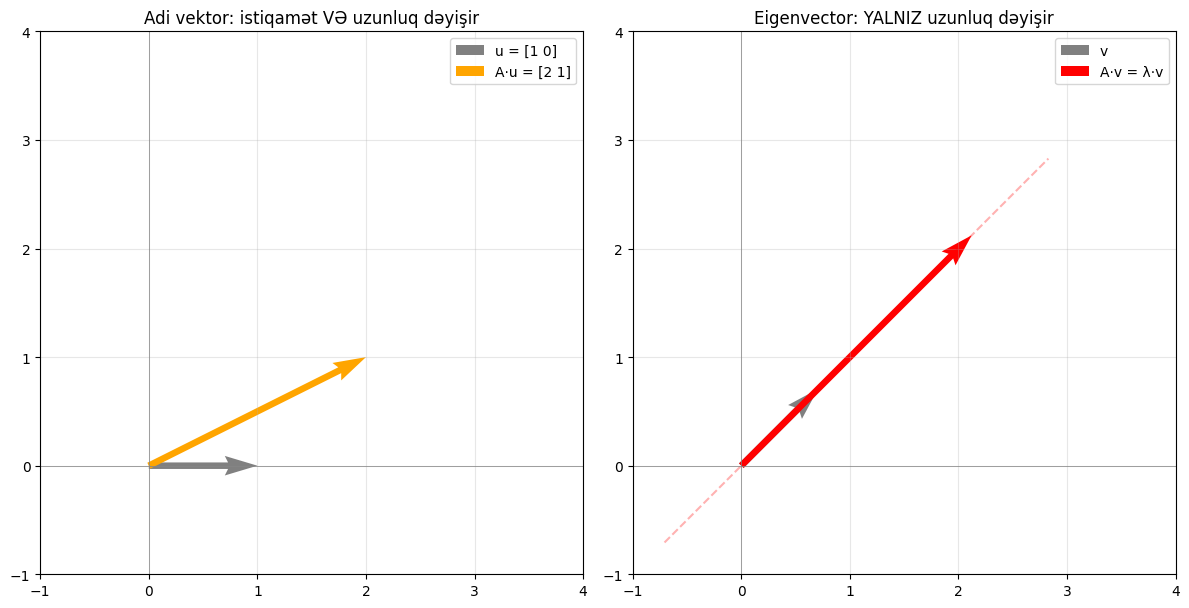

In [12]:
A = np.array([[2, 1], [1, 2]])

# Adi vektor — eigenvector DEYİL
u = np.array([1, 0])
Au = A @ u

# Müqayisə üçün bir eigenvector
eigenvalues, eigenvectors = np.linalg.eig(A)
v = eigenvectors[:, 0]   # v1
Av = A @ v

# Bucaq hesabla (dərəcə ilə)
def bucaq_derece(a, b):
    cos_t = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    cos_t = np.clip(cos_t, -1, 1)  # float xətalarına qarşı
    return np.degrees(np.arccos(cos_t))

print("ADİ VEKTOR (u = [1, 0]):")
print(f"  u  = {u}, uzunluq = {np.linalg.norm(u):.3f}")
print(f"  Au = {Au}, uzunluq = {np.linalg.norm(Au):.3f}")
print(f"  İstiqamət dəyişikliyi: {bucaq_derece(u, Au):.2f}°")
print()
print("EIGENVECTOR (v = v1):")
print(f"  v  = {v}, uzunluq = {np.linalg.norm(v):.3f}")
print(f"  Av = {Av}, uzunluq = {np.linalg.norm(Av):.3f}")
print(f"  İstiqamət dəyişikliyi: {bucaq_derece(v, Av):.2f}°")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# SOL: adi vektor
ax = axes[0]
ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1,
          color='gray', label=f'u = {u}', width=0.012)
ax.quiver(0, 0, Au[0], Au[1], angles='xy', scale_units='xy', scale=1,
          color='orange', label=f'A·u = {Au}', width=0.012)
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Adi vektor: istiqamət VƏ uzunluq dəyişir')
ax.legend()

# SAĞ: eigenvector
ax = axes[1]
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='gray', label=f'v', width=0.012)
ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1,
          color='red', label=f'A·v = λ·v', width=0.012)
# Eigenvector xətti
t = np.linspace(-1, 4, 100)
ax.plot(t * v[0], t * v[1], 'r--', alpha=0.3)
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('Eigenvector: YALNIZ uzunluq dəyişir')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
R = np.array([[0, -1], [1, 0]])
eigenvalues, eigenvectors = np.linalg.eig(R)

print("Eigenvalues:")
print(eigenvalues)
print()
print("Eigenvectors:")
print(eigenvectors)

v = eigenvectors[:, 0]
lam = eigenvalues[0]

sol = R @ v
sag = lam * v

print(f"R·v = {sol}")
print(f"λ·v = {sag}")
print(f"Bərabər? {np.allclose(sol, sag)}")

Eigenvalues:
[0.+1.j 0.-1.j]

Eigenvectors:
[[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]
R·v = [0.        +0.70710678j 0.70710678+0.j        ]
λ·v = [0.        +0.70710678j 0.70710678+0.j        ]
Bərabər? True


In [16]:
np.random.seed(42)

n = 100
x = np.random.randn(n)
y = 0.7 * x + 0.3 * np.random.randn(n)

data = np.column_stack([x, y])

print(f"Data shape: {data.shape}")
print(f"İlk 5 nöqtə:\n{data[:5]}")

Data shape: (100, 2)
İlk 5 nöqtə:
[[ 0.49671415 -0.07691132]
 [-0.1382643  -0.22297861]
 [ 0.64768854  0.35056762]
 [ 1.52302986  0.82543772]
 [-0.23415337 -0.21229308]]


In [17]:
data_centered = data - data.mean(axis=0)

C = (data_centered.T @ data_centered) / (n - 1)

print(f"Covariance matrisi:\n{C}")


C_numpy = np.cov(data.T)
print(f"\nnp.cov nəticəsi:\n{C_numpy}")
print(f"\nBərabər? {np.allclose(C, C_numpy)}")

Covariance matrisi:
[[0.82476989 0.54189267]
 [0.54189267 0.43636609]]

np.cov nəticəsi:
[[0.82476989 0.54189267]
 [0.54189267 0.43636609]]

Bərabər? True


In [20]:
eigenvalues, eigenvectors = np.linalg.eig(C)

# Eigenvalue-ları azalan sıraya düz (PCA konvensiyası)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (sütun-sütun):\n{eigenvectors}")

# Hər bir eigenvalue ümumi yayılmadan neçə faiz tutur?
total_var = eigenvalues.sum()
print(f"\nYayılmanın payı:")
print(f"  PC1: {eigenvalues[0]/total_var*100:.1f}%")
print(f"  PC2: {eigenvalues[1]/total_var*100:.1f}%")

Eigenvalues: [1.20620854 0.05492744]
Eigenvectors (sütun-sütun):
[[ 0.81773058 -0.57560116]
 [ 0.57560116  0.81773058]]

Yayılmanın payı:
  PC1: 95.6%
  PC2: 4.4%


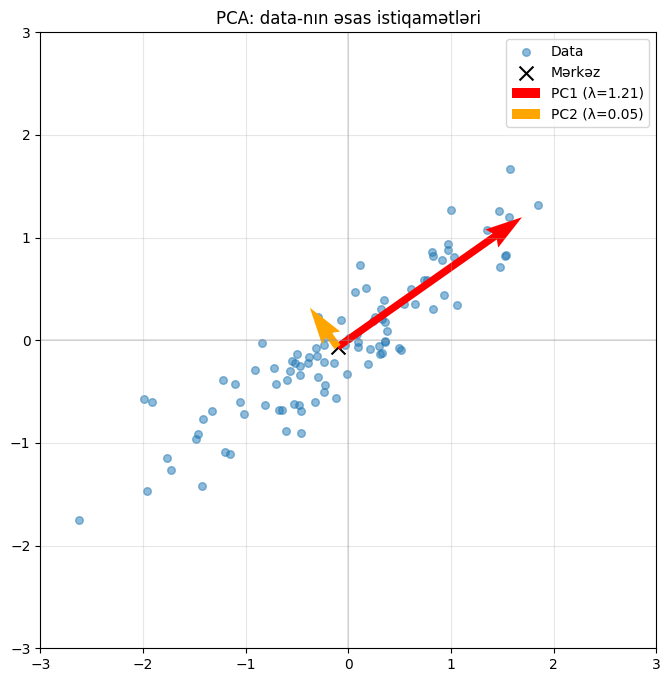

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

# Data nöqtələri
ax.scatter(data[:, 0], data[:, 1], alpha=0.5, s=30, label='Data')

# Mərkəz
mean = data.mean(axis=0)
ax.scatter(*mean, color='black', s=100, marker='x', label='Mərkəz')

# Eigenvector-ları çək — uzunluqları eigenvalue ilə miqyaslanmış
# (yəni nə qədər vacibdirsə, o qədər uzun göstəririk)
for i in range(2):
    v = eigenvectors[:, i]
    # Eigenvalue-nun kvadrat kökü standart sapma kimidir
    scale = 2 * np.sqrt(eigenvalues[i])
    ax.quiver(mean[0], mean[1], v[0]*scale, v[1]*scale,
              angles='xy', scale_units='xy', scale=1,
              color=['red', 'orange'][i], width=0.012,
              label=f'PC{i+1} (λ={eigenvalues[i]:.2f})')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axhline(0, color='gray', linewidth=0.3)
ax.axvline(0, color='gray', linewidth=0.3)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title('PCA: data-nın əsas istiqamətləri')
ax.legend()
plt.show()